# Online Shoppers — Imbalanced Classification

This case study builds a binary classifier for online purchase intention using the **Online Shoppers Purchasing Intention** dataset from the UCI Machine Learning Repository.

The project focuses on three related but distinct modeling problems:

- ranking sessions by purchase likelihood;
- selecting an operating threshold under class imbalance;
- producing calibrated probabilities that can support downstream decision-making.

The target is `Revenue`, indicating whether a browsing session ended in a purchase.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from ucimlrepo import fetch_ucirepo

from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

## 2. Data loading and quality checks

The original dataset contains 12,330 sessions, 17 predictors, and the binary target `Revenue`. UCI reports no missing values.

An exact-duplicate audit identified 125 duplicated rows. Because the dataset is intended to represent distinct sessions from distinct users, exact duplicate records are removed before the train/test split to prevent identical observations from leaking across partitions.

In [2]:
dataset = fetch_ucirepo(id=468)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()["Revenue"]

df = X_raw.copy()
df["Revenue"] = y_raw

print("Raw shape:", df.shape)
display(df.head())

Raw shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

print("\nExact duplicates:", df.duplicated().sum())
print(
    "Duplicate feature vectors:",
    df.drop(columns=["Revenue"]).duplicated().sum()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
clean_df = df.drop_duplicates().reset_index(drop=True)

print("Clean shape:", clean_df.shape)
print("Rows removed:", len(df) - len(clean_df))

Clean shape: (12205, 18)
Rows removed: 125


## 3. Train/test split

The held-out test set is reserved before target-guided exploratory analysis. An 80/20 stratified split preserves the class distribution, and a fixed random seed makes the experiment reproducible.

In [5]:
X = clean_df.drop(columns=["Revenue"])
y = clean_df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (9764, 17)
Test shape: (2441, 17)


## 4. Class prevalence

In [6]:
class_counts = y_train.value_counts().sort_index()
positive_prevalence = y_train.mean()
negative_prevalence = 1 - positive_prevalence

display(
    pd.DataFrame({
        "count": class_counts,
        "proportion": class_counts / len(y_train)
    })
)

print("Positive prevalence:", positive_prevalence)

,count,proportion
Revenue,,
0,8238,0.843712
1,1526,0.156288


Positive prevalence: 0.15628840639082342


The positive class is a minority of the observations, so accuracy alone is not an adequate model-selection criterion. Average Precision is especially useful because its no-skill reference level is approximately the positive prevalence.

## 5. Exploratory analysis

In [7]:
eda_df = X_train.copy()
eda_df["Revenue"] = np.asarray(y_train).ravel()

In [8]:
def revenue_rate_by_category(df, column):
    result = (
        df.groupby(column)["Revenue"]
        .agg(revenue_rate="mean", count="size")
        .sort_values("revenue_rate", ascending=False)
    )

    display(result)

    plt.figure(figsize=(8, 4))
    plt.bar(result.index.astype(str), result["revenue_rate"])
    plt.axhline(
        df["Revenue"].mean(),
        linestyle="--",
        label="Overall prevalence"
    )
    plt.ylabel("Revenue rate")
    plt.xlabel(column)
    plt.title(f"Revenue rate by {column}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return result

,revenue_rate,count
VisitorType,,
New_Visitor,0.240919,1349
Other,0.235294,68
Returning_Visitor,0.141967,8347


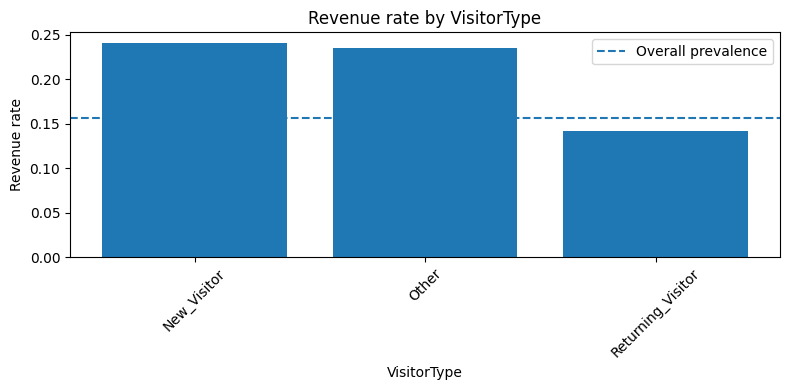

,revenue_rate,count
Weekend,,
True,0.174694,2284
False,0.150668,7480


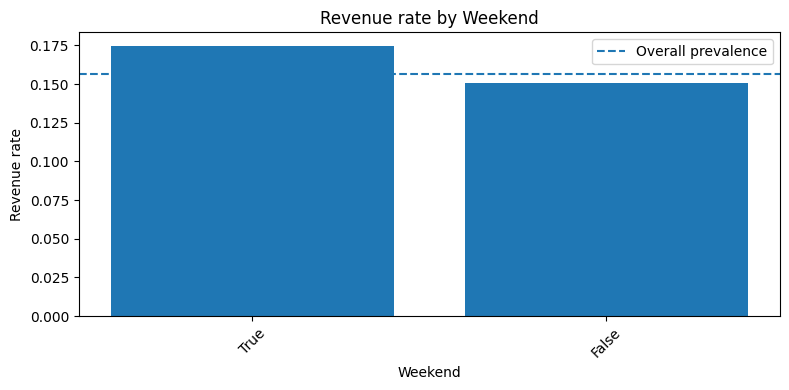

In [9]:
visitor_rates = revenue_rate_by_category(eda_df, "VisitorType")
weekend_rates = revenue_rate_by_category(eda_df, "Weekend")

,revenue_rate,count
Month,,
Feb,0.020833,144
Mar,0.106000,1500
May,0.106956,2674
June,0.102222,225
Jul,0.144476,353
Aug,0.172222,360
Sep,0.189266,354
Oct,0.224018,433
Nov,0.254029,2358


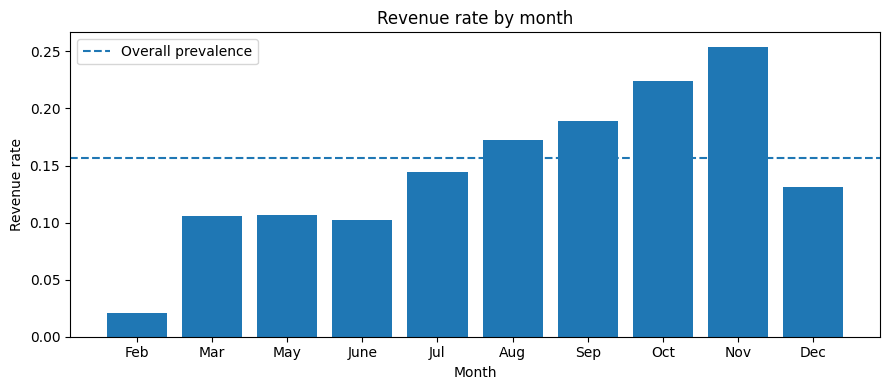

In [10]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_rates = (
    eda_df.groupby("Month")["Revenue"]
    .agg(revenue_rate="mean", count="size")
    .reindex([m for m in month_order if m in eda_df["Month"].unique()])
)

display(month_rates)

plt.figure(figsize=(9, 4))
plt.bar(month_rates.index, month_rates["revenue_rate"])
plt.axhline(
    eda_df["Revenue"].mean(),
    linestyle="--",
    label="Overall prevalence"
)
plt.ylabel("Revenue rate")
plt.xlabel("Month")
plt.title("Revenue rate by month")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
numeric_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

numeric_by_revenue = (
    eda_df.groupby("Revenue")[numeric_columns]
    .median()
    .T
)

numeric_by_revenue.columns = ["No Revenue", "Revenue"]

numeric_by_revenue["abs_median_difference"] = (
    numeric_by_revenue["Revenue"] -
    numeric_by_revenue["No Revenue"]
).abs()

display(
    numeric_by_revenue.sort_values(
        "abs_median_difference",
        ascending=False
    )
)

,No Revenue,Revenue,abs_median_difference
ProductRelated_Duration,530.812500,1122.915000,592.102500
Administrative_Duration,0.000000,49.300000,49.300000
PageValues,0.000000,16.359197,16.359197
ProductRelated,16.000000,29.000000,13.000000
Administrative,1.000000,2.000000,1.000000
ExitRates,0.028459,0.016290,0.012169
BounceRates,0.003774,0.000000,0.003774
Informational_Duration,0.000000,0.000000,0.000000
Informational,0.000000,0.000000,0.000000
SpecialDay,0.000000,0.000000,0.000000


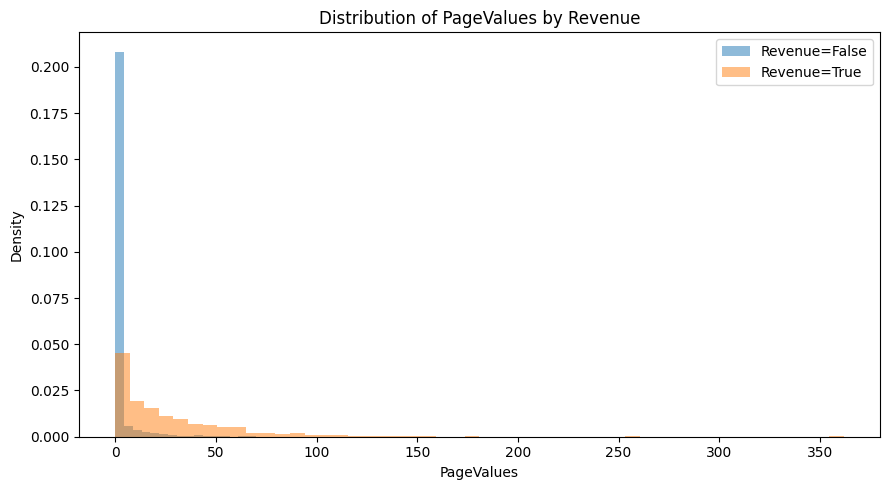

,zero_rate,median,mean
Revenue,,,
0,0.883588,0.000000,1.983595
1,0.195282,16.359197,27.334239


In [12]:
plt.figure(figsize=(9, 5))

for revenue_value in [False, True]:
    values = eda_df.loc[
        eda_df["Revenue"] == revenue_value,
        "PageValues"
    ]

    plt.hist(
        values,
        bins=50,
        alpha=0.5,
        density=True,
        label=f"Revenue={revenue_value}"
    )

plt.xlabel("PageValues")
plt.ylabel("Density")
plt.title("Distribution of PageValues by Revenue")
plt.legend()
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "zero_rate": eda_df.groupby("Revenue")["PageValues"]
            .apply(lambda x: (x == 0).mean()),
        "median": eda_df.groupby("Revenue")["PageValues"].median(),
        "mean": eda_df.groupby("Revenue")["PageValues"].mean(),
    })
)

ProductRelated            ProductRelated_Duration             
                median       mean                  median         mean
Revenue                                                               
0                 16.0  29.253581                530.8125  1089.592950
1                 29.0  47.477720               1122.9150  1842.507002

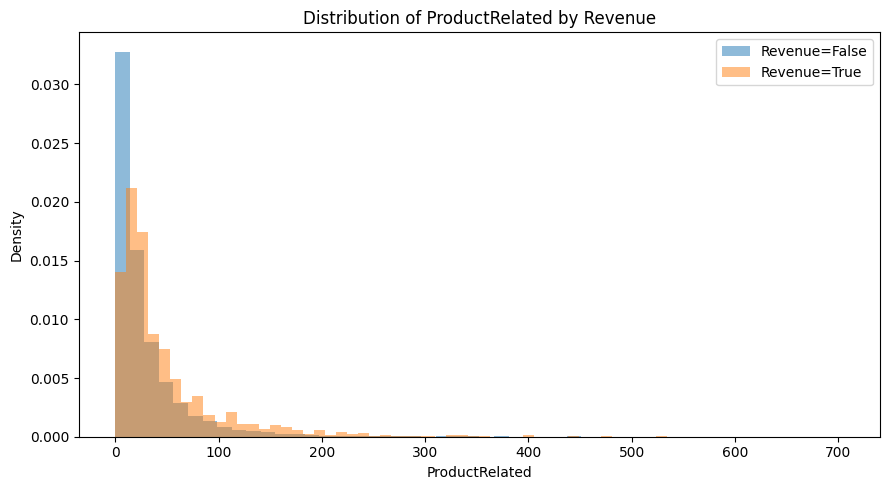

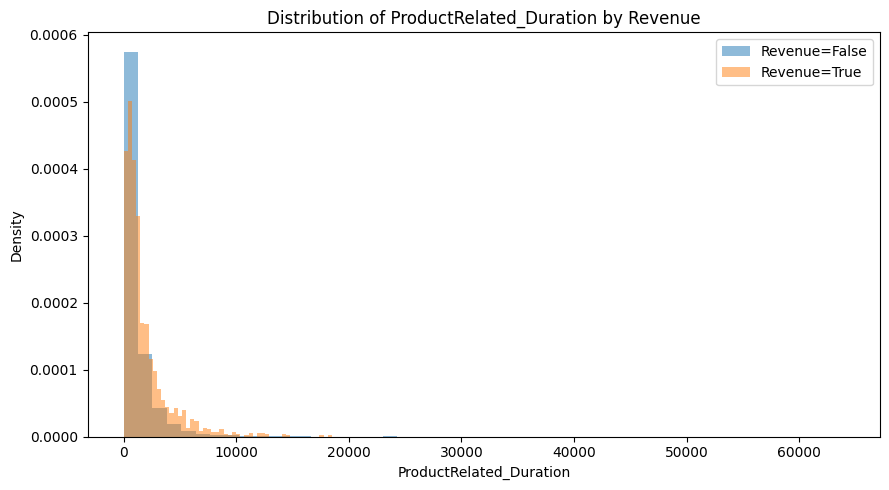

In [13]:
product_summary = (
    eda_df.groupby("Revenue")[
        ["ProductRelated", "ProductRelated_Duration"]
    ]
    .agg(["median", "mean"])
)

display(product_summary)

for feature in ["ProductRelated", "ProductRelated_Duration"]:
    plt.figure(figsize=(9, 5))

    for revenue_value in [False, True]:
        values = eda_df.loc[
            eda_df["Revenue"] == revenue_value,
            feature
        ]

        plt.hist(
            values,
            bins=50,
            alpha=0.5,
            density=True,
            label=f"Revenue={revenue_value}"
        )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"Distribution of {feature} by Revenue")
    plt.legend()
    plt.tight_layout()
    plt.show()

BounceRates           ExitRates          
             median      mean    median      mean
Revenue                                          
0          0.003774  0.023101  0.028459  0.045532
1          0.000000  0.005150  0.016290  0.019534

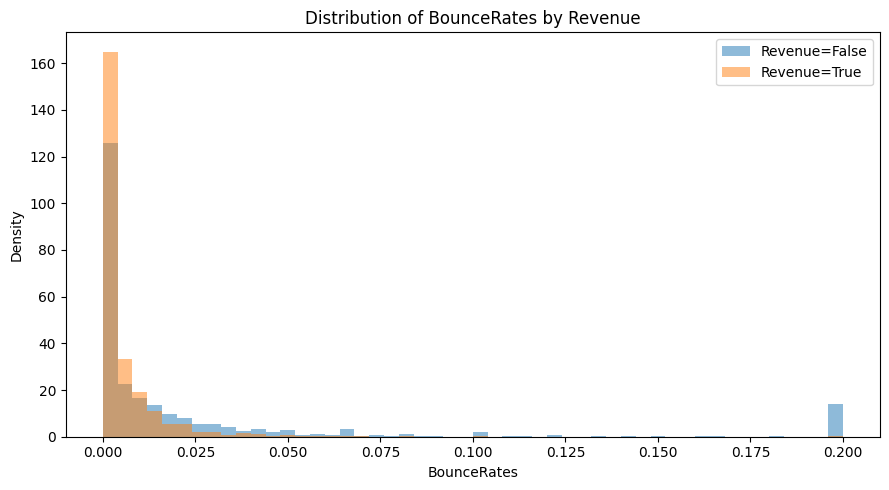

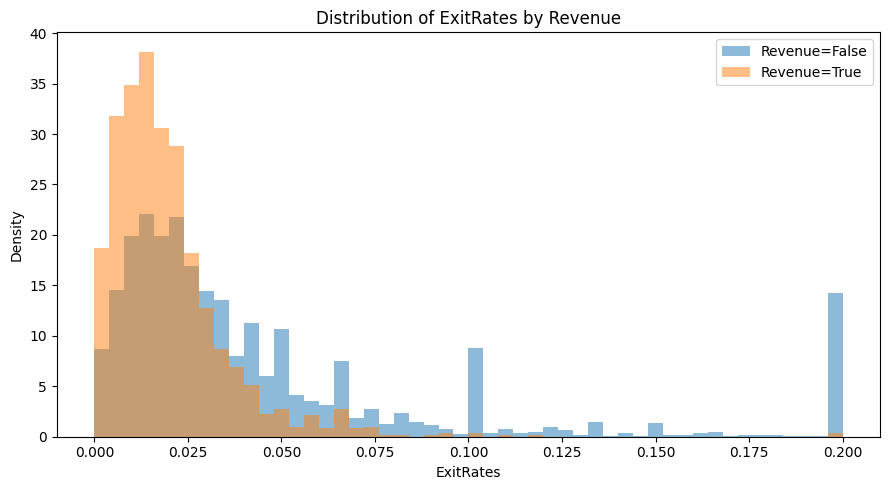

In [14]:
engagement_summary = (
    eda_df.groupby("Revenue")[
        ["BounceRates", "ExitRates"]
    ]
    .agg(["median", "mean"])
)

display(engagement_summary)

for feature in ["BounceRates", "ExitRates"]:
    plt.figure(figsize=(9, 5))

    for revenue_value in [False, True]:
        values = eda_df.loc[
            eda_df["Revenue"] == revenue_value,
            feature
        ]

        plt.hist(
            values,
            bins=50,
            alpha=0.5,
            density=True,
            label=f"Revenue={revenue_value}"
        )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"Distribution of {feature} by Revenue")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
skewness = (
    eda_df[numeric_columns]
    .skew()
    .sort_values(key=np.abs, ascending=False)
    .to_frame("skewness")
)

numeric_target_corr = (
    eda_df[numeric_columns + ["Revenue"]]
    .corr()["Revenue"]
    .drop("Revenue")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("correlation_with_revenue")
)

display(skewness)
display(numeric_target_corr)

,skewness
ProductRelated_Duration,7.871851
Informational_Duration,7.542680
PageValues,6.547283
Administrative_Duration,5.676854
ProductRelated,4.389816
Informational,4.098676
SpecialDay,3.268965
BounceRates,3.173039
ExitRates,2.236878
Administrative,1.986133


,correlation_with_revenue
PageValues,0.488122
ExitRates,-0.204597
ProductRelated,0.147667
BounceRates,-0.144115
ProductRelated_Duration,0.141933
Administrative,0.135084
SpecialDay,-0.086536
Informational,0.086463
Administrative_Duration,0.079256
Informational_Duration,0.065307


The training-set EDA shows meaningful differences between sessions that do and do not end in purchases. New visitors have a higher purchase rate than returning visitors, while the weekend effect is smaller. Purchase rates also vary by month, with stronger rates late in the year.

Sessions ending in purchases show greater product-page engagement and lower bounce and exit rates. `PageValues` stands out as the feature most strongly associated with the target. Because of that unusually strong relationship, it should be treated as an important availability and leakage-audit point in a production deployment.

## 6. Preprocessing and cross-validation

Continuous variables are standardized for Logistic Regression, while categorical variables are one-hot encoded. Integer-coded fields such as browser, region, operating system, and traffic source are treated as categories rather than continuous quantities.

The same preprocessing pipeline is reused across models for a consistent comparison.

In [16]:
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_columns),
    ("cat", categorical_transformer, categorical_columns),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [17]:
def get_scores(y_true, y_predicted, y_score=None):
    scores = {
        "accuracy": np.mean(y_true == y_predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_predicted),
        "recall": recall_score(y_true, y_predicted, zero_division=0),
        "precision": precision_score(y_true, y_predicted, zero_division=0),
        "f1": f1_score(y_true, y_predicted, zero_division=0),
        "f2": fbeta_score(
            y_true,
            y_predicted,
            beta=2,
            zero_division=0
        ),
        "roc_auc": None,
        "average_precision": None,
    }

    if y_score is not None:
        scores["roc_auc"] = roc_auc_score(y_true, y_score)
        scores["average_precision"] = average_precision_score(
            y_true,
            y_score
        )

    return scores


def cv_scores(model, cv, X, y):
    scorers = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "recall": make_scorer(recall_score, zero_division=0),
        "precision": make_scorer(precision_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
        "f2": make_scorer(
            fbeta_score,
            beta=2,
            zero_division=0
        ),
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
    }

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scorers,
        n_jobs=-1,
    )

    rows = []
    for score in scorers:
        values = cv_results[f"test_{score}"]
        rows.append({
            "metric": score,
            "mean": np.mean(values),
            "std": np.std(values),
        })

    result = pd.DataFrame(rows).set_index("metric")
    display(result)
    return result

## 7. Baseline

In [18]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent")),
])

baseline_cv = cv_scores(
    baseline_model,
    cv,
    X_train,
    y_train,
)

,mean,std
metric,,
accuracy,0.843712,0.000199
balanced_accuracy,0.500000,0.000000
recall,0.000000,0.000000
precision,0.000000,0.000000
f1,0.000000,0.000000
f2,0.000000,0.000000
roc_auc,0.500000,0.000000
average_precision,0.156288,0.000199


The majority-class baseline provides a useful reference for the imbalance problem: it can achieve superficially high accuracy while completely failing to identify positive sessions.

## 8. Base model comparison

In [19]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

print("Logistic Regression")
logistic_cv = cv_scores(
    logistic_model,
    cv,
    X_train,
    y_train,
)

print("\nRandom Forest")
rf_cv = cv_scores(
    random_forest_model,
    cv,
    X_train,
    y_train,
)

Logistic Regression


,mean,std
metric,,
accuracy,0.881811,0.004782
balanced_accuracy,0.674206,0.013905
recall,0.372204,0.028018
precision,0.743644,0.029170
f1,0.495569,0.028179
f2,0.413317,0.028470
roc_auc,0.888533,0.012187
average_precision,0.635554,0.021786



Random Forest


,mean,std
metric,,
accuracy,0.899529,0.002896
balanced_accuracy,0.739706,0.007711
recall,0.507209,0.015847
precision,0.771994,0.016331
f1,0.612005,0.012812
f2,0.544478,0.014770
roc_auc,0.922608,0.003227
average_precision,0.737249,0.017627


Random Forest provides the stronger overall ranking performance and substantially better recall at the default operating threshold, while maintaining precision close to Logistic Regression. It is therefore used as the main model family for the imbalance experiments.

## 9. Out-of-fold probabilities and threshold selection

Threshold-independent ranking metrics and threshold-dependent classification metrics answer different questions. Out-of-fold probabilities are used to study the operating threshold without using the held-out test set.

In [20]:
oof_proba = cross_val_predict(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

print("OOF ROC-AUC:", roc_auc_score(y_train, oof_proba))
print(
    "OOF Average Precision:",
    average_precision_score(y_train, oof_proba)
)

OOF ROC-AUC: 0.9224290098915076
OOF Average Precision: 0.7362392213406543


In [21]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    oof_proba,
)


def f_beta_curve(precision, recall, beta=1):
    numerator = (1 + beta**2) * precision * recall
    denominator = beta**2 * precision + recall

    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=float),
        where=denominator != 0,
    )


f1_results = f_beta_curve(
    precision[:-1],
    recall[:-1],
    beta=1,
)
f2_results = f_beta_curve(
    precision[:-1],
    recall[:-1],
    beta=2,
)

best_f1_idx = np.argmax(f1_results)
best_f2_idx = np.argmax(f2_results)

best_f1_threshold = thresholds[best_f1_idx]
best_f2_threshold = thresholds[best_f2_idx]

precision_at_f1_opt = precision[best_f1_idx]
recall_at_f1_opt = recall[best_f1_idx]

precision_at_f2_opt = precision[best_f2_idx]
recall_at_f2_opt = recall[best_f2_idx]

best_f1 = f_beta_curve(
    np.array([precision_at_f1_opt]),
    np.array([recall_at_f1_opt]),
    beta=1,
)[0]

best_f2 = f_beta_curve(
    np.array([precision_at_f2_opt]),
    np.array([recall_at_f2_opt]),
    beta=2,
)[0]

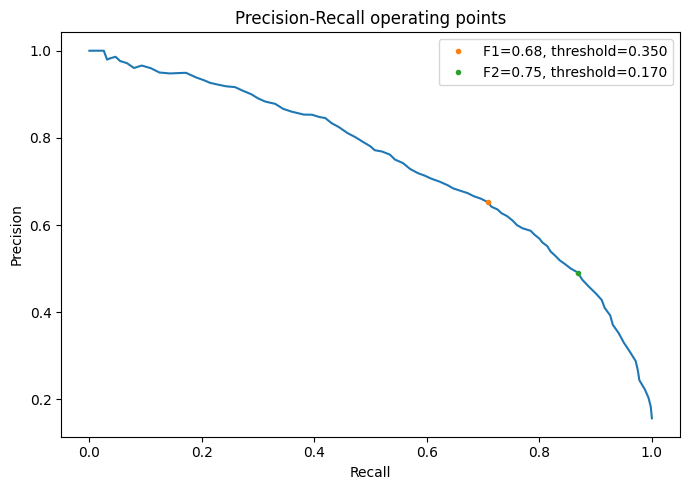

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.plot(
    recall_at_f1_opt,
    precision_at_f1_opt,
    ".",
    label=(
        f"F1={best_f1:.2f}, "
        f"threshold={best_f1_threshold:.3f}"
    ),
)
plt.plot(
    recall_at_f2_opt,
    precision_at_f2_opt,
    ".",
    label=(
        f"F2={best_f2:.2f}, "
        f"threshold={best_f2_threshold:.3f}"
    ),
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall operating points")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
threshold_results = []

for name, threshold in [
    ("Default", 0.5),
    ("Best F1", best_f1_threshold),
    ("Best F2", best_f2_threshold),
]:
    y_pred_threshold = oof_proba >= threshold
    scores = get_scores(
        y_train,
        y_pred_threshold,
        oof_proba,
    )

    threshold_results.append({
        "strategy": name,
        "threshold": threshold,
        "positive_rate": y_pred_threshold.mean(),
        "precision": scores["precision"],
        "recall": scores["recall"],
        "f1": scores["f1"],
        "f2": scores["f2"],
    })

display(pd.DataFrame(threshold_results))

,strategy,threshold,positive_rate,precision,recall,f1,f2
0,Default,0.50,0.105797,0.768635,0.520315,0.620555,0.556256
1,Best F1,0.35,0.169705,0.652384,0.708388,0.679233,0.696431
2,Best F2,0.17,0.276424,0.490923,0.868283,0.627219,0.752584


Lowering the decision threshold increases recall at the cost of precision. The F2 operating point explicitly favors recall, which is appropriate when missed potential purchasers are considered more costly than additional false positives.

## 10. Class weighting and SMOTENC

In [24]:
cw_random_forest_model = clone(random_forest_model)
cw_random_forest_model.set_params(
    classifier__class_weight="balanced"
)

print("Class-weighted Random Forest")
cw_rf_cv = cv_scores(
    cw_random_forest_model,
    cv,
    X_train,
    y_train,
)

Class-weighted Random Forest


,mean,std
metric,,
accuracy,0.894819,0.005212
balanced_accuracy,0.823401,0.009706
recall,0.719514,0.022172
precision,0.647837,0.021000
f1,0.681378,0.013012
f2,0.703646,0.016452
roc_auc,0.924466,0.004396
average_precision,0.728000,0.018473


In [25]:
X_train_smote = X_train.copy()

for column in categorical_columns:
    X_train_smote[column] = (
        X_train_smote[column].astype("category")
    )

random_forest_smote_model = ImbPipeline([
    (
        "smote",
        SMOTENC(
            categorical_features="auto",
            random_state=RANDOM_STATE,
        ),
    ),
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

print("SMOTENC Random Forest")
smote_rf_cv = cv_scores(
    random_forest_smote_model,
    cv,
    X_train_smote,
    y_train,
)

SMOTENC Random Forest


,mean,std
metric,,
accuracy,0.886624,0.006414
balanced_accuracy,0.816683,0.015941
recall,0.714938,0.032742
precision,0.619108,0.018196
f1,0.663236,0.020274
f2,0.693222,0.026695
roc_auc,0.914269,0.005495
average_precision,0.658442,0.020903


In [26]:
strategy_comparison = pd.concat(
    {
        "Standard RF": rf_cv["mean"],
        "Class-weighted RF": cw_rf_cv["mean"],
        "SMOTENC RF": smote_rf_cv["mean"],
    },
    axis=1,
)

display(strategy_comparison)

,Standard RF,Class-weighted RF,SMOTENC RF
metric,,,
accuracy,0.899529,0.894819,0.886624
balanced_accuracy,0.739706,0.823401,0.816683
recall,0.507209,0.719514,0.714938
precision,0.771994,0.647837,0.619108
f1,0.612005,0.681378,0.663236
f2,0.544478,0.703646,0.693222
roc_auc,0.922608,0.924466,0.914269
average_precision,0.737249,0.728000,0.658442


Both imbalance interventions move the default operating point toward higher recall. Class weighting achieves the better overall trade-off for this analysis: it improves positive-class detection while preserving ranking quality more effectively than SMOTENC. SMOTENC reaches similar recall but produces a larger drop in Average Precision.

## 11. Probability calibration

Class weighting and oversampling can improve classification behavior while changing the probability distribution produced by the model. Calibration is therefore evaluated separately from discrimination.

In [27]:
oof_standard = cross_val_predict(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

oof_class_weighted = cross_val_predict(
    cw_random_forest_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

oof_smote = cross_val_predict(
    random_forest_smote_model,
    X_train_smote,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

brier_comparison = pd.Series({
    "Standard RF": brier_score_loss(
        y_train,
        oof_standard,
    ),
    "Class-weighted RF": brier_score_loss(
        y_train,
        oof_class_weighted,
    ),
    "SMOTENC RF": brier_score_loss(
        y_train,
        oof_smote,
    ),
}, name="Brier score")

display(brier_comparison.to_frame())

,Brier score
Standard RF,0.072614
Class-weighted RF,0.078059
SMOTENC RF,0.083984


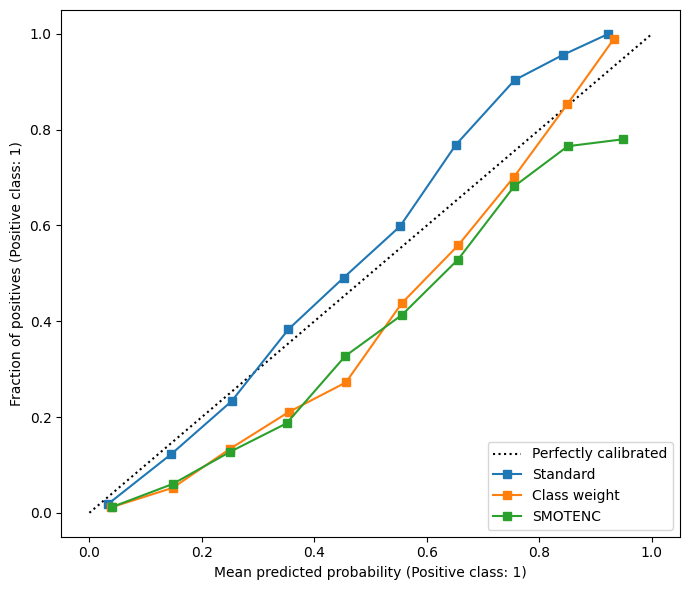

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_train,
    oof_standard,
    n_bins=10,
    name="Standard",
    ax=ax,
)

CalibrationDisplay.from_predictions(
    y_train,
    oof_class_weighted,
    n_bins=10,
    name="Class weight",
    ax=ax,
)

CalibrationDisplay.from_predictions(
    y_train,
    oof_smote,
    n_bins=10,
    name="SMOTENC",
    ax=ax,
)

plt.tight_layout()
plt.show()

,Brier score
Before calibration,0.078059
After calibration,0.071398


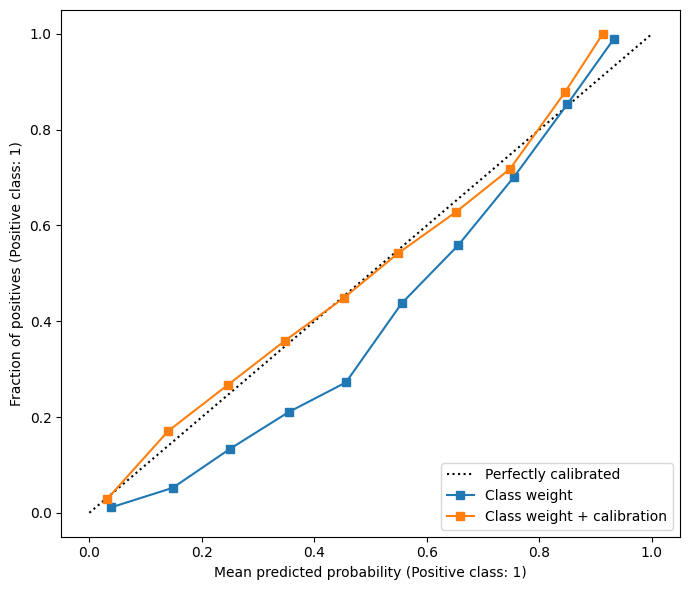

In [29]:
exploratory_calibrated_cw_model = CalibratedClassifierCV(
    estimator=cw_random_forest_model,
    method="sigmoid",
    cv=cv,
    n_jobs=-1,
)

oof_calibrated_class_weighted = cross_val_predict(
    exploratory_calibrated_cw_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

calibration_brier_comparison = pd.Series({
    "Before calibration": brier_score_loss(
        y_train,
        oof_class_weighted,
    ),
    "After calibration": brier_score_loss(
        y_train,
        oof_calibrated_class_weighted,
    ),
}, name="Brier score")

display(calibration_brier_comparison.to_frame())

fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_train,
    oof_class_weighted,
    n_bins=10,
    name="Class weight",
    ax=ax,
)

CalibrationDisplay.from_predictions(
    y_train,
    oof_calibrated_class_weighted,
    n_bins=10,
    name="Class weight + calibration",
    ax=ax,
)

plt.tight_layout()
plt.show()

The class-weighted model is retained because it offers the strongest recall-oriented trade-off without the larger ranking degradation observed with SMOTENC. Sigmoid calibration is added because the weighted model's raw probabilities are less well calibrated than those from the standard Random Forest.

## 12. Hyperparameter tuning and final model

In [30]:
param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 3, 5],
    "classifier__max_features": ["sqrt", 0.5],
}

search = GridSearchCV(
    estimator=clone(cw_random_forest_model),
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("Best parameters:")
print(search.best_params_)

print("\nBest CV Average Precision:")
print(search.best_score_)

Best parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 400}

Best CV Average Precision:
0.7515067852224903


In [31]:
print("Cross-validation performance of tuned weighted RF")
tuned_rf_cv = cv_scores(
    best_rf,
    cv,
    X_train,
    y_train,
)

Cross-validation performance of tuned weighted RF


,mean,std
metric,,
accuracy,0.870648,0.004597
balanced_accuracy,0.850999,0.009628
recall,0.822415,0.021358
precision,0.558728,0.010542
f1,0.665239,0.010300
f2,0.751336,0.014833
roc_auc,0.933069,0.004151
average_precision,0.751507,0.021684


In [32]:
final_calibrated_model = CalibratedClassifierCV(
    estimator=best_rf,
    method="sigmoid",
    cv=3,
    n_jobs=-1,
)

final_oof_proba = cross_val_predict(
    final_calibrated_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

default_oof_pred = final_oof_proba >= 0.5

default_calibrated_scores = get_scores(
    y_train,
    default_oof_pred,
    final_oof_proba,
)

display(
    pd.Series(
        default_calibrated_scores,
        name="OOF score at threshold 0.5",
    ).to_frame()
)

print(
    "Brier score:",
    brier_score_loss(y_train, final_oof_proba)
)

,OOF score at threshold 0.5
accuracy,0.902089
balanced_accuracy,0.803958
recall,0.661206
precision,0.696823
f1,0.678547
f2,0.668035
roc_auc,0.933274
average_precision,0.751552


Brier score: 0.0704285495117922


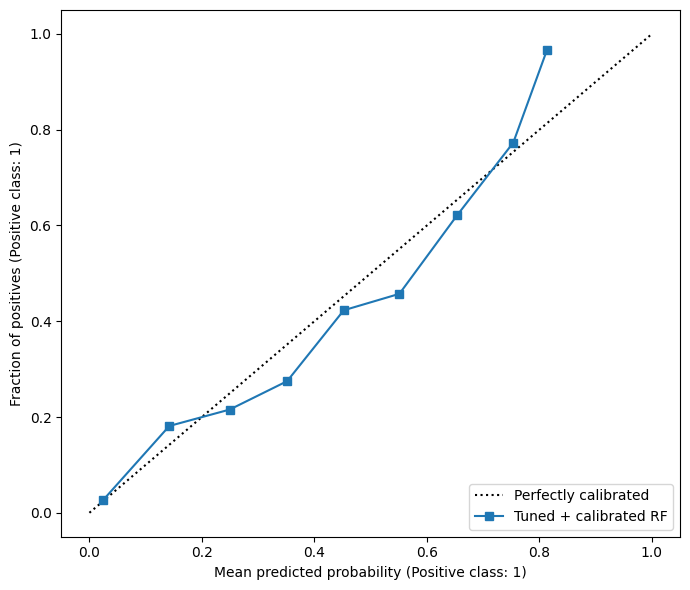

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_train,
    final_oof_proba,
    n_bins=10,
    name="Tuned + calibrated RF",
    ax=ax,
)

plt.tight_layout()
plt.show()

In [34]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    final_oof_proba,
)

f2_values = f_beta_curve(
    precision[:-1],
    recall[:-1],
    beta=2,
)

best_threshold_idx = np.argmax(f2_values)
final_threshold = thresholds[best_threshold_idx]

final_oof_pred = final_oof_proba >= final_threshold

print("Selected F2 threshold:", final_threshold)

display(
    pd.Series(
        get_scores(
            y_train,
            final_oof_pred,
            final_oof_proba,
        ),
        name="OOF score at selected threshold",
    ).to_frame()
)

Selected F2 threshold: 0.1243764197536622


,OOF score at selected threshold
accuracy,0.849549
balanced_accuracy,0.855579
recall,0.864351
precision,0.511042
f1,0.642318
f2,0.759355
roc_auc,0.933274
average_precision,0.751552


The final workflow consists of a tuned class-weighted Random Forest, sigmoid probability calibration, and an operating threshold selected from out-of-fold probabilities by maximizing F2. Model selection, calibration assessment, and threshold selection are completed using the training data only.

## 13. Held-out test evaluation

In [35]:
final_model = clone(final_calibrated_model)
final_model.fit(X_train, y_train)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = test_proba >= final_threshold

test_scores = get_scores(
    y_test,
    test_pred,
    test_proba,
)

display(
    pd.Series(
        test_scores,
        name="Test score",
    ).to_frame()
)

print(
    "Test Brier score:",
    brier_score_loss(y_test, test_proba)
)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))

,Test score
accuracy,0.849242
balanced_accuracy,0.860531
recall,0.876963
precision,0.510671
f1,0.645472
f2,0.766941
roc_auc,0.934816
average_precision,0.745226


Test Brier score: 0.07028225744227785

Confusion matrix:
[[1738  321]
 [  47  335]]


In [36]:
oof_vs_test = pd.DataFrame({
    "OOF": {
        "precision": precision_score(
            y_train,
            final_oof_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_train,
            final_oof_pred,
            zero_division=0,
        ),
        "f2": fbeta_score(
            y_train,
            final_oof_pred,
            beta=2,
            zero_division=0,
        ),
    },
    "Test": {
        "precision": precision_score(
            y_test,
            test_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            test_pred,
            zero_division=0,
        ),
        "f2": fbeta_score(
            y_test,
            test_pred,
            beta=2,
            zero_division=0,
        ),
    },
})

display(oof_vs_test)

,OOF,Test
precision,0.511042,0.510671
recall,0.864351,0.876963
f2,0.759355,0.766941


The held-out evaluation checks whether the recall-oriented operating point selected from out-of-fold predictions transfers to unseen data. The final comparison focuses on both ranking quality and the precision-recall trade-off rather than accuracy alone.

## 14. Key takeaways

- The target is sufficiently imbalanced that accuracy alone gives an incomplete view of performance.
- Random Forest produced stronger ranking and recall than Logistic Regression in the base comparison.
- Threshold selection materially changes the precision-recall operating point without changing the underlying ranking.
- Class weighting improved positive-class recall while preserving ranking quality better than SMOTENC in this experiment.
- Resampling and class weighting can affect probability calibration even when ranking metrics remain strong.
- Sigmoid calibration was incorporated before selecting the final operating threshold.
- The final threshold was selected from out-of-fold probabilities using F2, keeping the held-out test set isolated until the final evaluation.